### STEP:1 Importing the libraries

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 2: Load the dataset

In [27]:
df = pd.read_csv("messy_data.csv")
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32,USD 858,########,10%
1,1/30/2024,north,Tablet,Electronics,72,$833.83,########,15 percent
2,2/13/2024,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,4/28/2024,West,Laptop,gadget,thirty,$733.46,########,0.1
4,2/18/2024,EAST,Phone,ELEC,47,USD 373,"40,920",0.1


### STEP 3: Check for Missing values and info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               200 non-null    object
 1   Region             200 non-null    object
 2   Product            200 non-null    object
 3   Category           200 non-null    object
 4   Units Sold         196 non-null    object
 5   Unit Price         200 non-null    object
 6   Total Sales        197 non-null    object
 7   Profit Margin (%)  200 non-null    object
dtypes: object(8)
memory usage: 12.6+ KB


### STEP 4: Handling Missing values nan

In [6]:
df.isnull().sum()

Date                 0
Region               0
Product              0
Category             0
Units Sold           4
Unit Price           0
Total Sales          3
Profit Margin (%)    0
dtype: int64

### Ensure numeric columns are numeric before filling Nan

In [31]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors = "coerce")
df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors = "coerce")

### Filling Missing Numeric values with column mean


In [32]:
df["Units Sold"] = df["Units Sold"].fillna(df["Units Sold"].mean())
df["Total Sales"] = df["Total Sales"].fillna(df["Total Sales"].mean())
df[["Units Sold","Total Sales"]]

,Units Sold,Total Sales
0,32.000000,26096.323077
1,72.000000,26096.323077
2,52.307692,26096.323077
3,52.307692,26096.323077
4,47.000000,26096.323077
...,...,...
195,52.307692,23607.000000
196,52.307692,26096.323077
197,91.000000,26096.323077
198,52.307692,41246.000000


In [39]:
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32.000000,USD 858,26096.323077,10%
1,1/30/2024,north,Tablet,Electronics,72.000000,$833.83,26096.323077,15 percent
2,2/13/2024,EAST,laptop,ELEC,52.307692,489.12,26096.323077,0.08
3,4/28/2024,West,Laptop,gadget,52.307692,$733.46,26096.323077,0.1
4,2/18/2024,EAST,Phone,ELEC,47.000000,USD 373,26096.323077,0.1


### Clean Column Names (remove leading/trailing Spaces)

In [40]:
df.columns = df.columns.str.strip()
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32.000000,USD 858,26096.323077,10%
1,1/30/2024,north,Tablet,Electronics,72.000000,$833.83,26096.323077,15 percent
2,2/13/2024,EAST,laptop,ELEC,52.307692,489.12,26096.323077,0.08
3,4/28/2024,West,Laptop,gadget,52.307692,$733.46,26096.323077,0.1
4,2/18/2024,EAST,Phone,ELEC,47.000000,USD 373,26096.323077,0.1


### Fix Data formates (turn inconsistent text into real date format)

In [41]:
df["Date"] = pd.to_datetime(df["Date"], errors= "coerce")

In [44]:
df["Date"].head()

0   2024-01-15
1          NaT
2          NaT
3          NaT
4          NaT
Name: Date, dtype: datetime64[ns]

In [46]:
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26096.323077,10%
1,NaT,north,Tablet,Electronics,72.000000,$833.83,26096.323077,15 percent
2,NaT,EAST,laptop,ELEC,52.307692,489.12,26096.323077,0.08
3,NaT,West,Laptop,gadget,52.307692,$733.46,26096.323077,0.1
4,NaT,EAST,Phone,ELEC,47.000000,USD 373,26096.323077,0.1


### Standardize text columns (make names consistent and neat)


In [51]:
for col in ["Region", "Product", "Category"]:
    df[col] = df[col].str.strip().str.title()

In [53]:
df[["Region", "Product", "Category"]].head()

,Region,Product,Category
0,North,Tablet,Electronics
1,North,Tablet,Electronics
2,East,Laptop,Elec
3,West,Laptop,Gadget
4,East,Phone,Elec


### Convert Units Sold to numeric (turn words like 'twenty' into NaN)

In [54]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors = "coerce")

In [57]:
### Clean Currency columns (Unit Price, Total Sales)
for col in ["Unit Price", "Total Sales"]:
    df[col] = df[col].astype(str)
    df[col] = (
    df[col]
        .str.replace("[$, USD]", "", regex = True)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors = "coerce")

In [59]:
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26096.323077,10%
1,NaT,North,Tablet,Electronics,72.000000,833.83,26096.323077,15 percent
2,NaT,East,Laptop,Elec,52.307692,489.12,26096.323077,0.08
3,NaT,West,Laptop,Gadget,52.307692,733.46,26096.323077,0.1
4,NaT,East,Phone,Elec,47.000000,373.00,26096.323077,0.1


In [63]:
df["Profit Margin (%)"] = (
    df["Profit Margin (%)"]
    .astype(str)
    .str.replace("%", "", regex= True)
    .str.replace("percent", "", regex= True)
    .astype(float)
)
df["Profit Margin (%)"] = np.where(df["Profit Margin (%)"] < 1, df["Profit Margin (%)"] * 100, df["Profit Margin (%)"])

In [64]:
df_cleaned = df.dropna(subset=["Date", "Total Sales", "Region"])

In [67]:
df_cleaned.head(10)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26096.323077,10.0
5,2024-04-03,South,Laptop,Gadgets,52.307692,670.28,3103.000000,8.0
7,2024-03-15,West,Tablet,Gadgets,47.000000,241.65,26096.323077,12.0
8,2024-01-09,West,Phone,Gadget,52.307692,796.00,26096.323077,8.0
10,2024-01-26,South,Desktop,Elec,52.307692,100.76,26096.323077,8.0
12,2024-04-06,North,Tablet,Elec,52.307692,548.00,26096.323077,8.0
14,2024-03-03,South,Tablet,Elec,52.307692,348.60,7352.000000,8.0
18,2024-03-03,South,Laptop,Electronics,28.000000,655.07,26096.323077,8.0
23,2024-01-20,East,Desktop,Gadget,52.307692,803.81,26096.323077,15.0
25,2024-04-25,South,Tablet,Electronics,52.307692,540.16,26096.323077,10.0


### Total sales by region

C:\Users\subha\AppData\Local\Temp\ipykernel_21944\3911026417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_cleaned, x = "Region", y = "Total Sales", estimator = sum, palette = "cool")


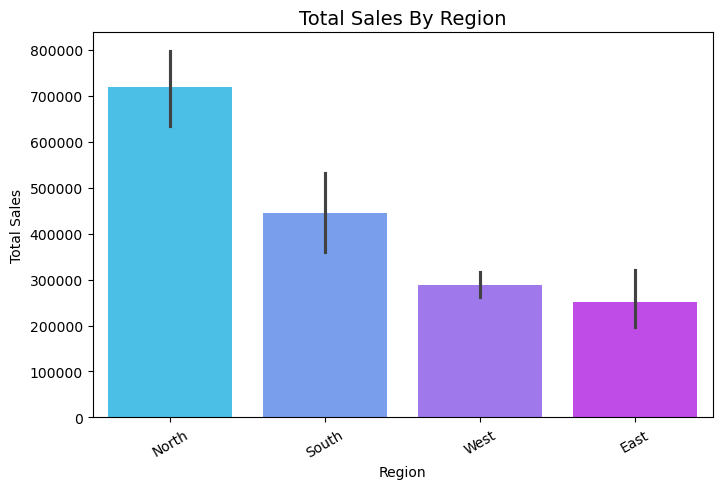

In [68]:
plt.figure(figsize=(8,5))
sns.barplot(data = df_cleaned, x = "Region", y = "Total Sales", estimator = sum, palette = "cool")
plt.title("Total sales by region".title(), fontsize = 14)
plt.xticks(rotation=30)
plt.show()

# Category Share Pie Chart

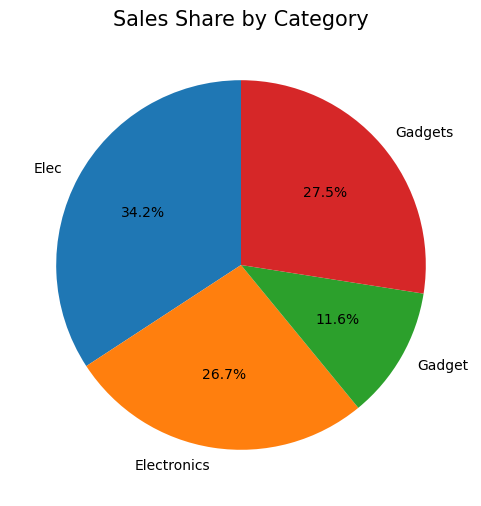

In [72]:
plt.figure(figsize=(6,6))
category_sales = df_cleaned.groupby("Category")["Total Sales"].sum()
category_sales.plot(kind="pie", autopct="%1.1f%%", startangle=90, color = sns.color_palette("pastel"))
plt.title("Sales Share by Category", fontsize = 15)
plt.ylabel("")
plt.show()